# Technical Exercise
## Analysis and comparison of biosignals using different sensors

We have two datasets collected using distinct biomedical devices (`data` folder): `FPdata.xls` and `labchartdata.csv`

### Data Properties:
- `FPdata.xls`:
    - Recorded in a discontinuous manner with nonlinear sampling rate: time stamps correspond to detected start time of a beat;
    - Labeled based on the pressure stage during which the recording was made (Baseline, Stage1, Stage 2). It is not confirmed when the start and end of the FP recording was made relative to pressure chamber stage changes.
- `labchartdata.csv`:
    - Recorded continuously from start to finish with a sampling rate of 1000 Hz.
- Both:
    - Recordings do not necessarily have the same start time;
    - Common metric between 2 datasets: Heart rate (HR).

**Metrics to compare: Cardiac output (CO; `labchartdata.csv`) and Velocity time integral (VTI; `FPdata.xls`).**

In [1]:
import pandas as pd, numpy as np, os, sys
from scipy.interpolate import interp1d
from scipy import signal, stats
import matplotlib.pyplot as plt, seaborn as sns

sys.path.append(os.path.abspath(os.path.join("..")))
from src.loaders import load_data
from src.plotters import plot_HR_by_stage, plot_co_vti_overlay
from src.processors import get_running_time, get_stage_offset
from src.analyzers import build_analysis_df, _stage_metrics

fp_data, labchart_data = load_data('../data/')

## Exploratory Data Analysis / Pre-Processing
We are told that the `FPdata.xls` was recorded in a discontinuous manner with a non-linear sampling rate, and was labeled by stage. We can visualize this with our helper function (`src/plotters.py`). 

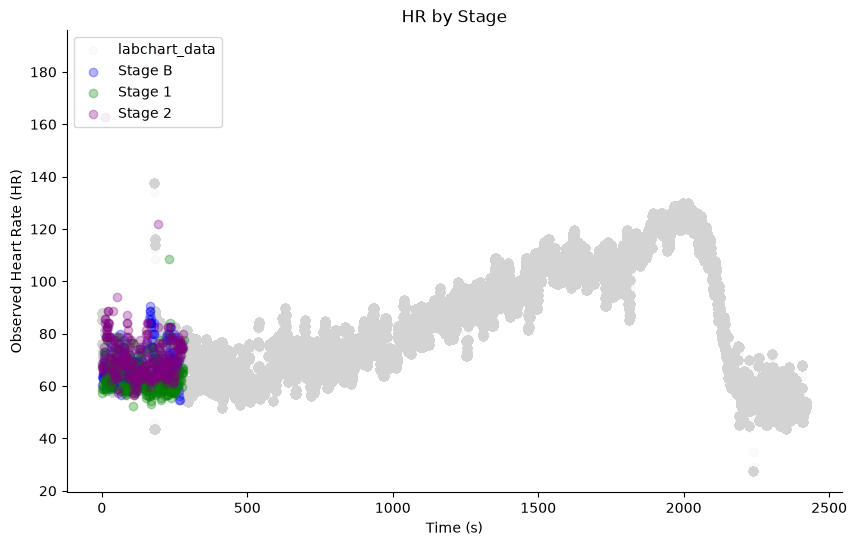

In [2]:
plot_HR_by_stage(fp_data, ref_data=labchart_data, stage_col='Stage', time_col='Time (s)', hr_col='HR')  

It's clear that we need to fix the timeline for the measurements, as the clock restarts at each stage. It is not clear when the start/end of the recording happened relative to the stage changes, but as a first pass we can concatenate the three stages into one running timeline by offsetting each stage's time by the end of the previous one. 

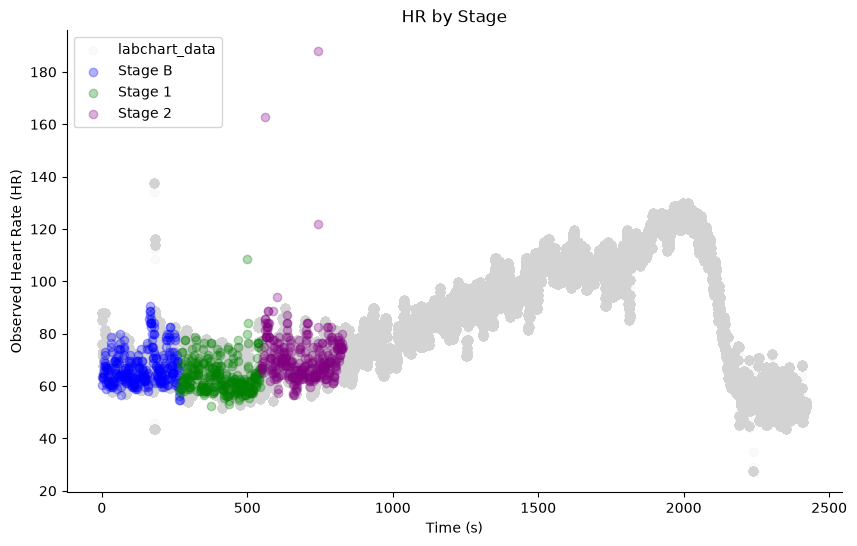

In [3]:
get_running_time(fp_data)
plot_HR_by_stage(fp_data, ref_data=labchart_data, stage_col='Stage', time_col='Corrected Time (s)', hr_col='HR')

# sanity check
labchart_data.sort_values('TimeSec', inplace=True, ascending=True)
fp_data.sort_values('Corrected Time (s)', inplace=True, ascending=True)

Okay, this looks a little more like it! We still need to account for some offset between stages, but at least we have a continuous timeline. We also observe some (what look like) erroneous readings; we can consider outlier filtration on both datasets as a future step for tigher alignment and/or improved metric quantification/comparison. 

For now, we'll focus on determinging the stage-specific offsets. To do this, we will use cross-correlation, which is a technique used to measure the similarity of two signals by sliding one relative to the other. This can be visualized below (*[visual credit](https://medium.com/data-science/four-ways-to-quantify-synchrony-between-time-series-data-b99136c4a9c9)*).

How it works:

1. **Sliding Match:** A small template or signal moves step-by-step across another target signal or image.
2. **Similarity Score:** At each step, it calculates a value showing how closely the two shapes match.
3. **Peak Detection:** The highest peak in the output graph shows the exact point of best alignment or time delay (lag).

![Cross Correlation Visualized.](../data/assets/crosscorr.gif)

There is still the matter of non-linear sampling rates for the fp_data and overall differences in sampling frequency between fp_data and labchart_data. To handle this, we will resample both datasets to a consistent, shared frequency, with a preference for downsampling labchart_data versus upsampling fp_data (minimize artificial/interpolated data and lower computational cost).

Once both datasets are resampled, we will perform cross-correlation using the heart rate (HR) signal to determine the stage-specific offsets (`src/processors.py`).

In [4]:
stages = fp_data['Stage'].unique()
time_offsets = {stage: get_stage_offset(stage, fp_data, labchart_data) for stage in stages}

Stage: B
Stage window: 0.528 s to 267.903 s
Estimated sampling frequencies -> labchart window: 1000.000 Hz, fp stage B: 1.085 Hz
Using shared resample frequency: 1.085 Hz
Calculated Time Delay: 18.432 seconds
--------------------------------------------------
Stage: 1
Stage window: 268.616 s to 549.126 s
Estimated sampling frequencies -> labchart window: 1000.000 Hz, fp stage 1: 1.030 Hz
Using shared resample frequency: 1.030 Hz
Calculated Time Delay: 37.859 seconds
--------------------------------------------------
Stage: 2
Stage window: 549.138 s to 827.302 s
Estimated sampling frequencies -> labchart window: 1000.000 Hz, fp stage 2: 1.146 Hz
Using shared resample frequency: 1.146 Hz
Calculated Time Delay: 61.071 seconds
--------------------------------------------------


Now we can apply the stage-specific offsets to synchronize the signals.

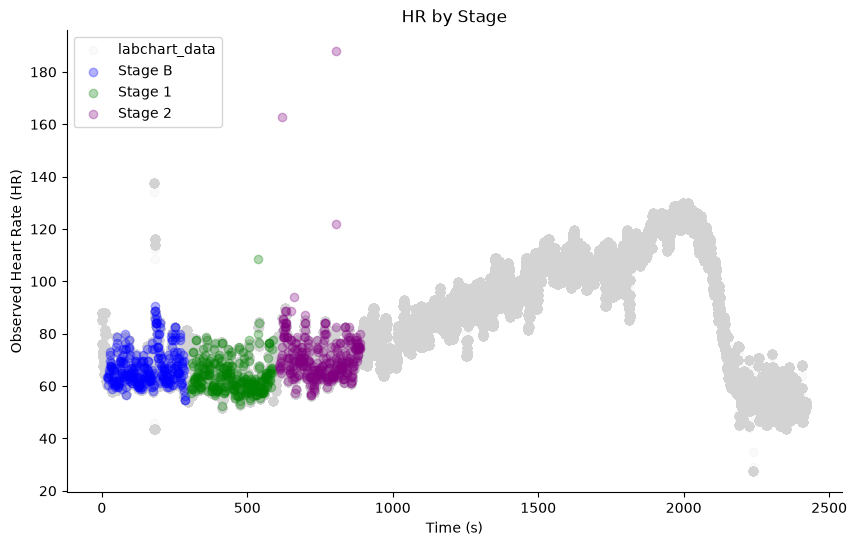

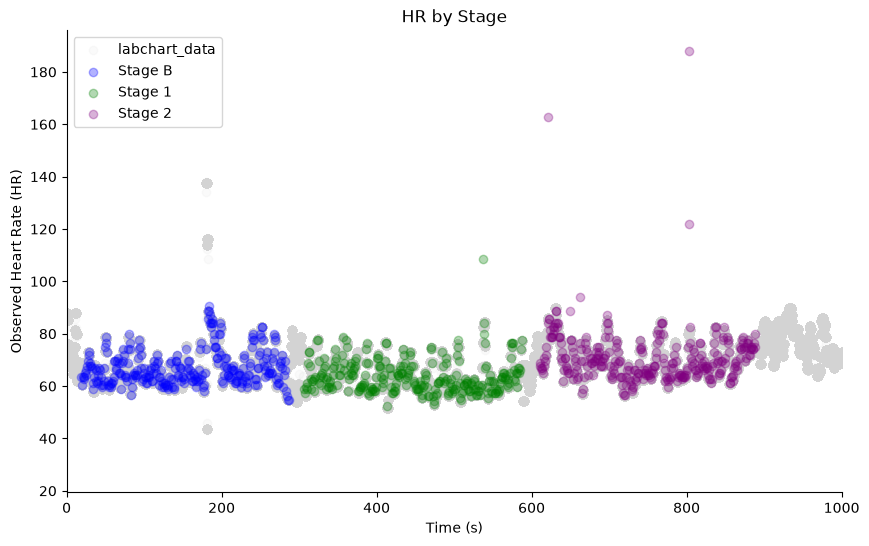

In [5]:
for stage, offset in time_offsets.items():
    mask = fp_data['Stage'] == stage
    fp_data.loc[mask, 'Corrected Time (s)'] = fp_data.loc[mask, 'Corrected Time (s)'] + offset

plot_HR_by_stage(fp_data, ref_data=labchart_data, stage_col='Stage', time_col='Corrected Time (s)', hr_col='HR')
plot_HR_by_stage(fp_data, ref_data=labchart_data, stage_col='Stage', time_col='Corrected Time (s)', hr_col='HR', xlim=(0, 1000))    


That's more like it, woohoo! Now when we're looking at quantitative metrics from these datasets, it's more likely we're comparing apples with apples (so to speak). Now we can approximate the labchart_data at the exact sampling times for fp_data for metric comparison and consolidate relevant information into a final, analysis dataframe.

In [6]:
analysis_df = build_analysis_df(fp_data, labchart_data, remove_invalid=True) # remove_invalid removes any CO or VTI values <=0 b/c not possible physiologically

## Statistical Analysis of CO vs VTI

We made it! Let's take a look at CO and VTI on the time domain of interest.

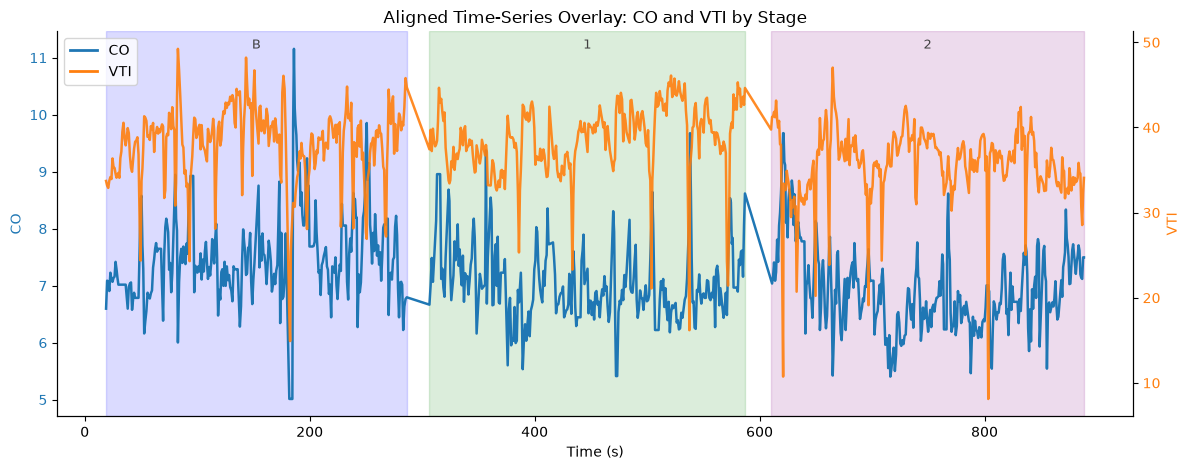

In [7]:
plot_co_vti_overlay(analysis_df, stage_order=['B', '1', '2'])

Both signals clearly co-fluctuate at a similar cadence. The peaks and troughs of CO and VTI often line up in time (e.g. around ~180s there is a sharp CO dip that VTI also dips near), and stay roughly in the same ranges throughout the stages.

Now, we'll look at the stage-wise summary table: n, Pearson r, Spearman rho, p-values, linear slope/intercept, and R^2.

In [8]:
stage_summary = analysis_df.groupby('Stage', observed=True).apply(_stage_metrics)

overall_summary = _stage_metrics(analysis_df).to_frame().T
overall_summary.index = ['Overall']

summary_stats = pd.concat([stage_summary, overall_summary], axis=0)
summary_stats

,n,pearson_r,pearson_p,spearman_rho,spearman_p,slope,intercept,R2
1,278.0,-0.314667,8.337288e-08,-0.372208,1.457558e-10,-1.952769,52.435474,0.099015
2,310.0,-0.426056,4.213631e-15,-0.439414,4.574001e-16,-2.515064,53.149428,0.181524
B,292.0,-0.256072,9.375534e-06,-0.399669,1.263284e-12,-1.422564,48.673302,0.065573
Overall,880.0,-0.256455,1.105919e-14,-0.261184,3.433683e-15,-1.484214,48.025730,0.065769


2. Scatter plots with regression confidence bands.
3. Normalized Bland-Altman plot (z-scored signals because CO and VTI are in different units).

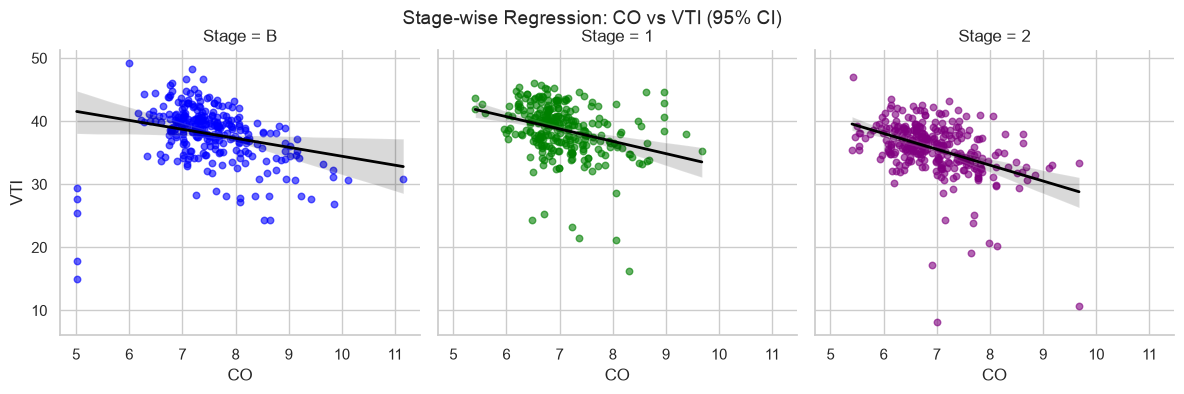

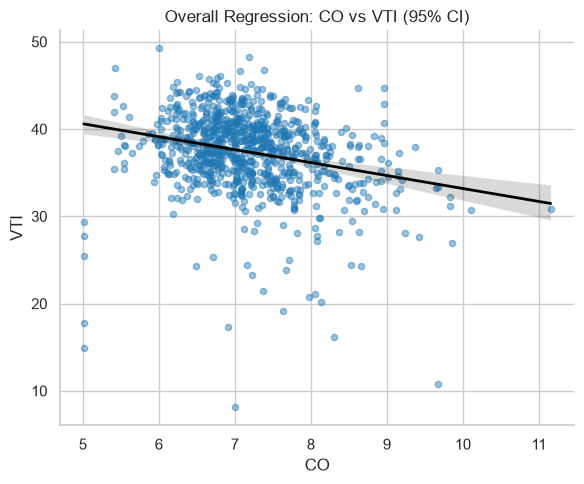

In [15]:
# Scatter + regression with 95% confidence bands
sns.set_theme(style='whitegrid', context='notebook')
palette = ['blue', 'green', 'purple']

g = sns.lmplot(
    data=analysis_df,
    x='CO',
    y='VTI',
    col='Stage',
    col_wrap=3,
    hue='Stage',
    palette=palette,
    # col_wrap=min(3, max(1, analysis_df['Stage'].nunique())),
    height=4,
    scatter_kws={'alpha': 0.6, 's': 22},
    line_kws={'color': 'black', 'lw': 2},
    ci=95,
)
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle('Stage-wise Regression: CO vs VTI (95% CI)', fontsize=14)
plt.show()

plt.figure(figsize=(6, 5))
sns.regplot(
    data=analysis_df,
    x='CO',
    y='VTI',
    scatter_kws={'alpha': 0.45, 's': 20},
    line_kws={'color': 'black', 'lw': 2},
    ci=95,
    color='tab:blue'
)
plt.title('Overall Regression: CO vs VTI (95% CI)')
plt.xlabel('CO')
plt.ylabel('VTI')
sns.despine()
plt.tight_layout()
plt.show()

In [10]:
stage_order = ['B', '1', '2']  # Manually set the stage order based on the known stages in the data
analysis_df['Stage'] = pd.Categorical(analysis_df['Stage'], categories=stage_order, ordered=True)

def _safe_zscore(series: pd.Series) -> pd.Series:
    std = series.std(ddof=0)
    if pd.isna(std) or std == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.mean()) / std

analysis_df['CO_z'] = _safe_zscore(analysis_df['CO'])
analysis_df['VTI_z'] = _safe_zscore(analysis_df['VTI'])

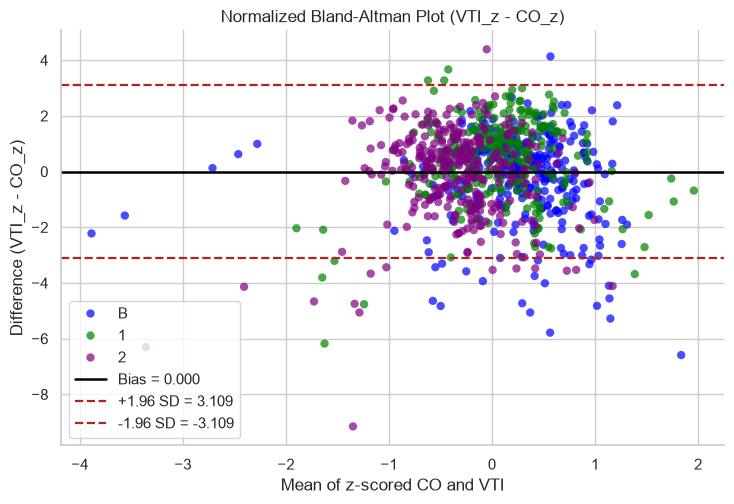

In [11]:
# Normalized Bland-Altman analysis (z-scored due to differing units)
ba_mean = (analysis_df['CO_z'] + analysis_df['VTI_z']) / 2
ba_diff = analysis_df['VTI_z'] - analysis_df['CO_z']

bias = ba_diff.mean()
sd_diff = ba_diff.std(ddof=1)
loa_upper = bias + 1.96 * sd_diff
loa_lower = bias - 1.96 * sd_diff

palette = ['blue', 'green', 'purple']

plt.figure(figsize=(7.5, 5.2))
sns.scatterplot(
    x=ba_mean,
    y=ba_diff,
    hue=analysis_df['Stage'],
    palette=palette,
    alpha=0.7,
    s=36,
    edgecolor='none'
)
plt.axhline(bias, color='black', linestyle='-', lw=1.8, label=f'Bias = {bias:.3f}')
plt.axhline(loa_upper, color='firebrick', linestyle='--', lw=1.6, label=f'+1.96 SD = {loa_upper:.3f}')
plt.axhline(loa_lower, color='firebrick', linestyle='--', lw=1.6, label=f'-1.96 SD = {loa_lower:.3f}')
plt.title('Normalized Bland-Altman Plot (VTI_z - CO_z)')
plt.xlabel('Mean of z-scored CO and VTI')
plt.ylabel('Difference (VTI_z - CO_z)')
plt.legend(loc='best')
sns.despine()
plt.tight_layout()
plt.show()

